In [7]:
# =========================================
# Cell 1 : import と環境確認
# =========================================

import torch
import torch.nn as nn

from openstl.models import SimVP_Model

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"
print("使用デバイス      :", device)

PyTorch version : 2.2.1+cu121
CUDA available  : True
使用デバイス      : cuda


In [8]:
# =========================================
# Cell 2 : SimVP モデル作成
# =========================================

model = SimVP_Model(
    in_shape       = (5, 2, 64, 64),   # (T_in, C, H, W)
    hid_S          = 64,
    hid_T          = 256,
    N_S            = 4,
    N_T            = 8,
    model_type     = "gSTA",
    pre_seq_length = 5,
    aft_seq_length = 10,
).to(device)

# パラメータ数確認
n_params = sum(p.numel() for p in model.parameters())

print(f"パラメータ数: {n_params:,}")

パラメータ数: 12,239,490


In [10]:
dummy_X = torch.randn(4, 5, 2, 64, 64).to(device)

# SimVP_Model 単体は 5 frame -> 5 frame
pred_1 = model(dummy_X)

# 10 frame 欲しい場合は、OpenSTL の wrapper と同じように2回呼ぶ
pred_2 = model(pred_1)

dummy_Y = torch.cat([pred_1, pred_2], dim=1)

print("入力 shape:", dummy_X.shape)
print("1回目出力 shape:", pred_1.shape)
print("2回結合後 shape:", dummy_Y.shape)

入力 shape: torch.Size([4, 5, 2, 64, 64])
1回目出力 shape: torch.Size([4, 5, 2, 64, 64])
2回結合後 shape: torch.Size([4, 10, 2, 64, 64])


In [11]:
import torch.nn as nn

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

dummy_target = torch.randn(4, 10, 2, 64, 64).to(device)

optimizer.zero_grad()

pred_1 = model(dummy_X)
pred_2 = model(pred_1)
pred = torch.cat([pred_1, pred_2], dim=1)

loss = criterion(pred, dummy_target)
loss.backward()
optimizer.step()

print("pred shape:", pred.shape)
print(f"loss: {loss.item():.6f}")

pred shape: torch.Size([4, 10, 2, 64, 64])
loss: 1.115384


In [12]:
# Cell 5 : ダミーデータ生成

import os
import numpy as np

os.makedirs("data", exist_ok=True)

N, T, H, W = 50, 15, 64, 64

dummy_z = np.random.rand(N, T, H, W).astype(np.float32)
dummy_A = (np.random.rand(N, T, H, W).astype(np.float32) * 1000)

np.save("data/all_z_dummy.npy", dummy_z)
np.save("data/all_A_dummy.npy", dummy_A)

print("ダミーデータ保存完了")
print("z:", dummy_z.shape)
print("A:", dummy_A.shape)

ダミーデータ保存完了
z: (50, 15, 64, 64)
A: (50, 15, 64, 64)


In [13]:
# Cell 6 : ミニ訓練ループ

from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import numpy as np
from openstl.models import SimVP_Model

class TerrainDataset(Dataset):
    def __init__(self, z_path, A_path):
        z = np.load(z_path)   # (N,15,H,W)
        A = np.load(A_path)

        z = (z - z.min()) / (z.max() - z.min() + 1e-8)
        A = np.log1p(A)
        A = (A - A.min()) / (A.max() - A.min() + 1e-8)

        # X: (N,5,2,H,W)
        self.X = torch.tensor(np.stack([z[:, :5], A[:, :5]], axis=2), dtype=torch.float32)

        # Y: (N,10,2,H,W)
        # 今の SimVP_Model は入力と同じ channel 数を返すため、target も2chにする
        self.Y = torch.tensor(np.stack([z[:, 5:], A[:, 5:]], axis=2), dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.Y[i]

def predict_10frames(model, X):
    pred_1 = model(X)          # (B,5,2,H,W)
    pred_2 = model(pred_1)     # (B,5,2,H,W)
    return torch.cat([pred_1, pred_2], dim=1)  # (B,10,2,H,W)

ds = TerrainDataset("data/all_z_dummy.npy", "data/all_A_dummy.npy")
loader = DataLoader(ds, batch_size=8, shuffle=True)

model = SimVP_Model(
    in_shape=(5, 2, 64, 64),
    hid_S=64,
    hid_T=256,
    N_S=4,
    N_T=8,
    model_type="gSTA",
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(3):
    model.train()

    for X, Y in loader:
        X, Y = X.to(device), Y.to(device)

        pred = predict_10frames(model, X)
        loss = criterion(pred, Y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} | loss: {loss.item():.6f}")

print("訓練ループ動作確認 完了")

Epoch 1 | loss: 0.066305
Epoch 2 | loss: 0.055150
Epoch 3 | loss: 0.053562
訓練ループ動作確認 完了


shape: (10, 120, 128, 128)
dtype: float64
min: -63.09367324149814
max: 225.85619435077342


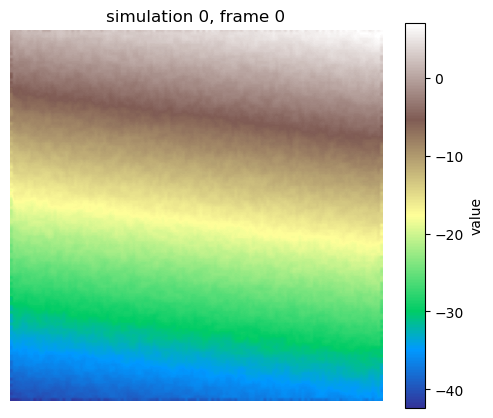

In [2]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import os

path = "all_z.npy"   # 必要なら "data/all_z.npy" に変更
x = np.load(path)

print("shape:", x.shape)
print("dtype:", x.dtype)
print("min:", np.nanmin(x))
print("max:", np.nanmax(x))

plt.figure(figsize=(6, 5))
plt.imshow(x[0, 0], cmap="terrain")
plt.colorbar(label="value")
plt.title("simulation 0, frame 0")
plt.axis("off")
plt.show()

In [3]:
import numpy as np

x = np.load("all_z.npy", allow_pickle=True)

print(type(x))

if isinstance(x, np.ndarray):
    print("単一配列です")
    print("shape:", x.shape)
else:
    print("配列以外:", x)

<class 'numpy.ndarray'>
単一配列です
shape: (10, 120, 128, 128)
